In [19]:
import matplotlib.pyplot as plt
import math
import sys
import numpy as np
import cv2
from pylab import *

In [20]:
#Image = cv2.imread('1.bmp', 1) # 1 as color image
#Image = cv2.cvtColor(Image, cv2.COLOR_BGR2GRAY)
Image = cv2.imread('brain.png', 0)
img = np.array(Image, dtype=np.float64)
img.shape

(132, 132)

In [21]:
print(img[0])
IniLSF = np.ones((img.shape[0], img.shape[1]), img.dtype)
#print(IniLSF.shape)
#print(IniLSF[20:50,40:50])
IniLSF[75:90,58:72] = -1
IniLSF = -IniLSF
print(IniLSF[30:80,30:80])
print(IniLSF.shape)


[ 30.  28.  25.  21.  21.  20.  16.  20.  45.  94. 126. 122.  82.  54.
  53.  62.  69.  69.  61.  45.  27.  13.  14.  29.  48.  59.  61.  65.
  59.  44.  27.  22.  24.  28.  26.  20.  15.  16.  26.  38.  48.  51.
  58.  66.  69.  63.  51.  42.  37.  38.  40.  42.  41.  38.  40.  38.
  37.  40.  42.  40.  45.  45.  43.  47.  58.  63.  61.  54.  56.  57.
  54.  55.  61.  59.  56.  51.  50.  50.  50.  51.  47.  43.  38.  36.
  37.  39.  40.  38.  39.  47.  52.  50.  44.  40.  41.  46.  57.  67.
  69.  61.  62.  79.  90.  92.  79.  68.  67.  70.  73.  70.  67.  65.
  64.  58.  53.  50.  51.  55.  66.  80.  89.  87.  89.  84.  73.  67.
  69.  65.  54.  49.  51.  49.]
[[-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 ...
 [-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]]
(132, 132)


In [22]:
print(IniLSF[20:60,20:60])


[[-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 ...
 [-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]]


C:\Users\mingw\AppData\Local\Temp\ipykernel_16544\3590178820.py:7: UserWarning: The following kwargs were not used by contour: 'color', 'linewidth'
  plt.contour(IniLSF, color='b', linewidth=2)


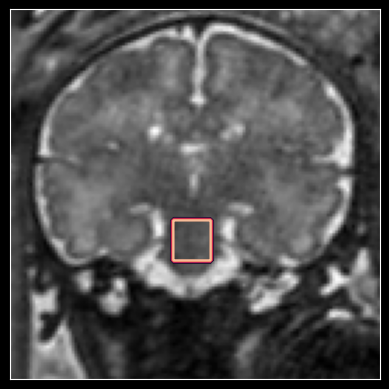

In [23]:
# Image = cv2.cvtColor(Image, cv2.COLOR_BGR2RGB)
plt.figure(1)
# plt.imshow(Image)
plt.imshow(Image, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.contour(IniLSF, color='b', linewidth=2)
plt.draw()
plt.show(block=False)

In [24]:
def mat_math(input, str):
    output = input
    for i in range(img.shape[0]):
        for j in range (img.shape[1]):
            if str == 'atan':
                output[i, j] = math.atan(input[i, j])
            if str == 'sqrt':
                output[i, j] = math.sqrt(input[i, j])
    return output


In [25]:
mu = 1
nu = 0.003 * 255 * 255
num = 20
epison = 1
step = 0.1
LSF=IniLSF
print(type(LSF), LSF.shape)

<class 'numpy.ndarray'> (132, 132)


LSF is a numpy.ndarray of shape (132, 132).
Mathematically it represents the level set function (\phi(x, y)).
The active contour (the segmentation boundary) is the zero level set: all points where LSF == 0.
Pixels with LSF > 0 are one region (e.g. "inside"), and LSF < 0 are the other region (e.g. "outside").
When LSF is near 0 (on/near the contour), the denominator epison*epison + LSF*LSF is small
(\Rightarrow) Drc is large.
When LSF is far from 0 (far inside or outside), the denominator is large
(\Rightarrow) Drc is close to 0.

In [26]:
def CV(LSF, img, mu, nu, reshape, step):
    #  Dirac delta function = (e / pi)  / (e * e + lsf * lsf)
    Drc = (epison / math.pi) / (epison*epison+ LSF*LSF)
    # H(z) = 1/2 ( 1 + 2 / pi * arctan(z/e)]  Heaviside function
    Hea = 0.5*(1 + (2 / math.pi)*mat_math(LSF/epison,"atan"))
    Iy, Ix = np.gradient(LSF)
    # gradient magnitude squared
    s = mat_math(Ix*Ix+Iy*Iy,"sqrt")
    Nx = Ix / (s+0.000001)
    Ny = Iy / (s+0.000001)
    Mxx,Nxx =np.gradient(Nx)
    Nyy,Myy =np.gradient(Ny)
    # Curvature (div(∇φ/|∇φ|))
    cur = Nxx + Nyy
    # Code: Length = nuDrccur Lap = cv2.Laplacian(LSF,-1) Penalty = mu*(Lap - cur)
    # u * length(c)
    Length = nu*Drc*cur

    #Discrete Laplacian (\Delta\phi).
    Lap = cv2.Laplacian(LSF,-1)
    Penalty = mu*(Lap - cur)

    # Code: s1=Hea*img s2=(1-Hea)*img C1 = s1.sum()/ Hea.sum() C2 = s2.sum()/ (1-Hea).sum()
    # Math: c1 (Average inside) and c2(Average outside)
    s1=Hea*img
    s2=(1-Hea)*img
    s3=1-Hea
    C1 = s1.sum()/ Hea.sum()
    C2 = s2.sum()/ s3.sum()
    CVterm = Drc*(-1 * (img - C1)*(img - C1) + 1 * (img - C2)*(img - C2))


    LSF = LSF + step*(Length + Penalty + CVterm)

    return LSF


C:\Users\mingw\AppData\Local\Temp\ipykernel_16544\1707717931.py:5: UserWarning: The following kwargs were not used by contour: 'linewidth'
  plt.contour(LSF,[0],colors='r',linewidth=2)


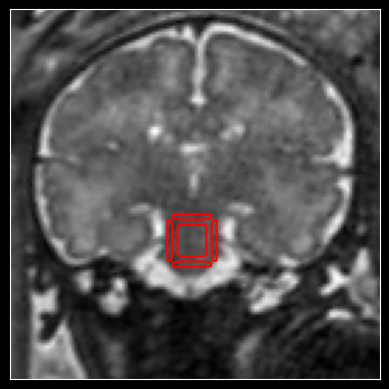

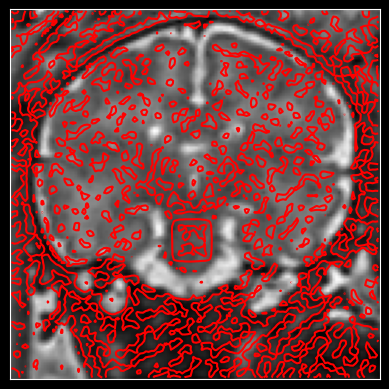

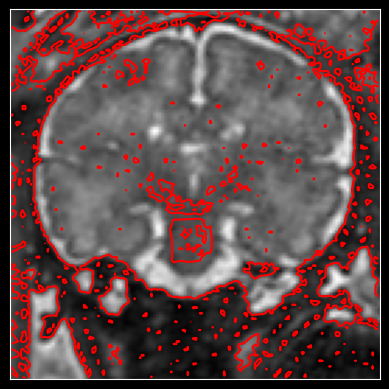

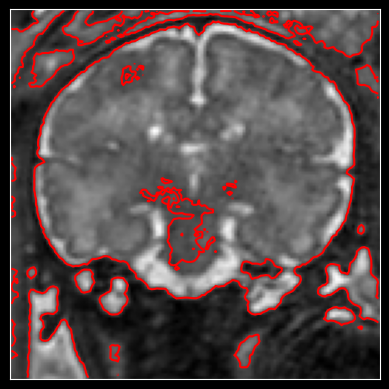

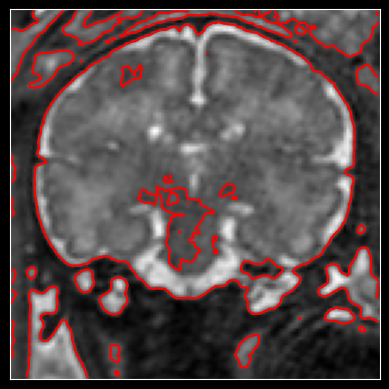

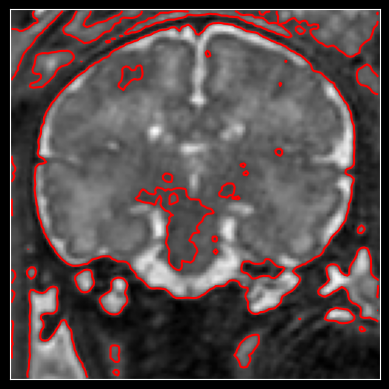

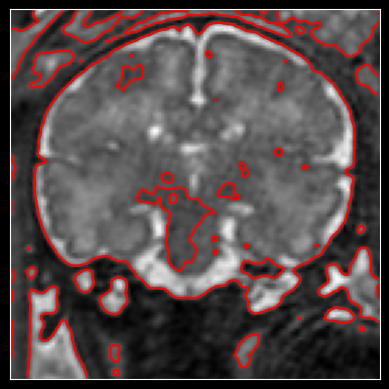

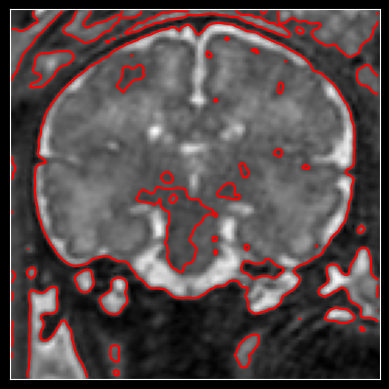

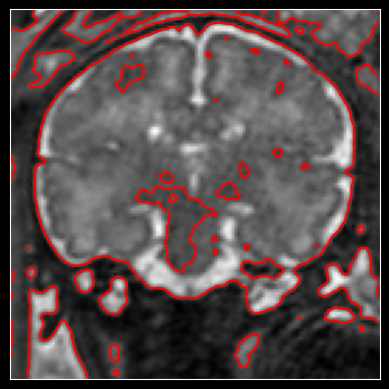

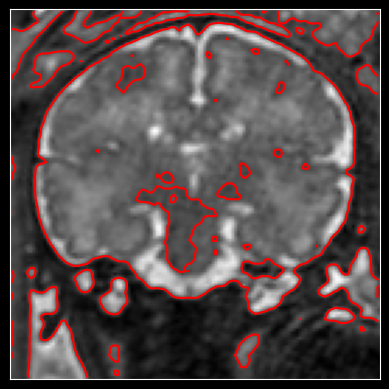

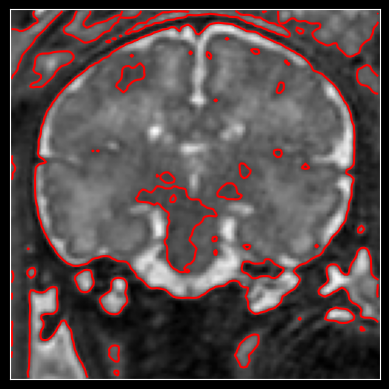

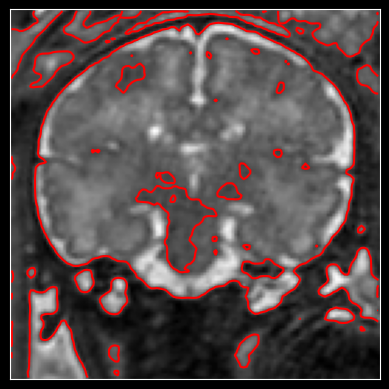

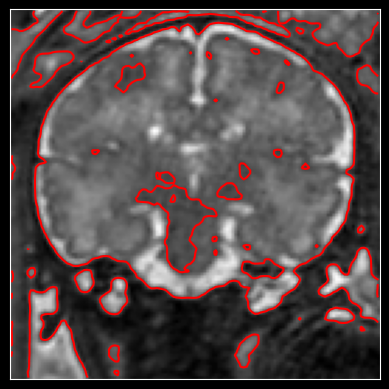

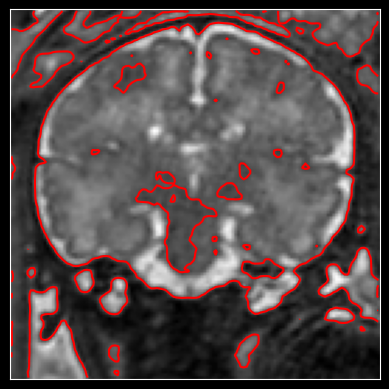

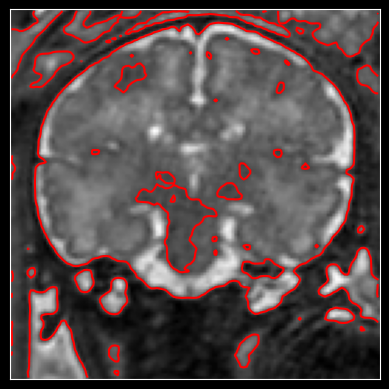

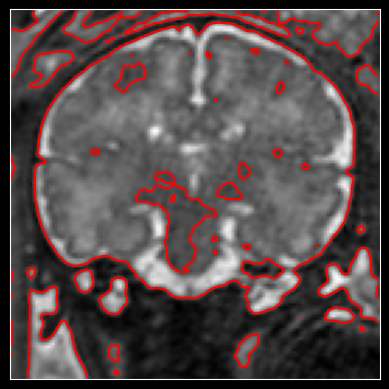

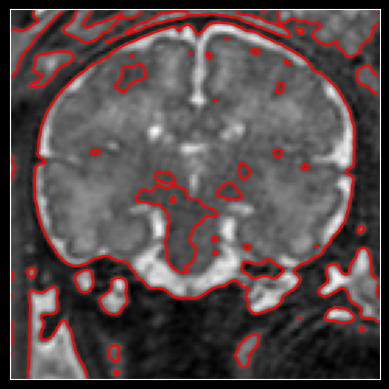

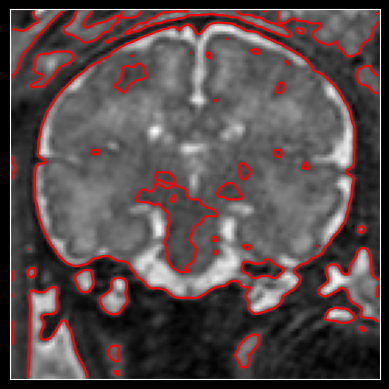

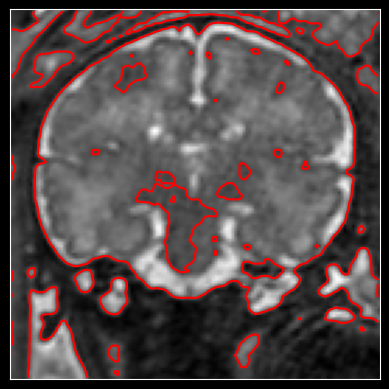

In [27]:
for i in range(1, num):
    LSF = CV(LSF, img, mu, nu, epison,step) #迭代
    if i % 1 == 0:    #显示分割轮廓
        plt.imshow(Image, cmap='gray'),plt.xticks([]), plt.yticks([])
        plt.contour(LSF,[0],colors='r',linewidth=2)
        plt.draw(),plt.show(block=False),plt.pause(0.01)
